# Gaussian Processes

Gaussian Processes are a statistical tool in Bayesian Learning that, through kernels,
are capable of fitting arbitrary functions. They are characterized through a mean
function $\mu$ and a covariance function $k$.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pai import GP
from selection import cross_validation
from scoring import neg_log_probability

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x = np.linspace(0, 4 * np.pi, 200).reshape((200, 1))
x_short = np.concatenate([x[:20], x[40:80], x[150:]])
y = np.sin(x_short) + rng.normal(0, 0.2, size=x_short.shape)

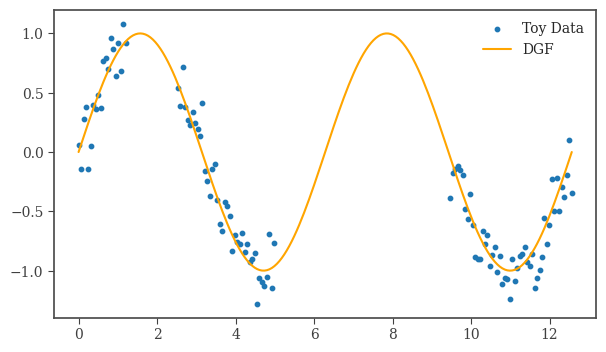

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y, label="Toy Data", s=10)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.legend()

plt.show()

## Fit a Gaussian Process

The reason why they are so strong is the fact that they are not limited to linear functions.
Furthermore, they not only predict a mean value, but also add uncertainty to their predictions.

In [4]:
gp = GP()

gp = gp.fit(x_short, y)
y_pred, y_cov = gp.predict(x)

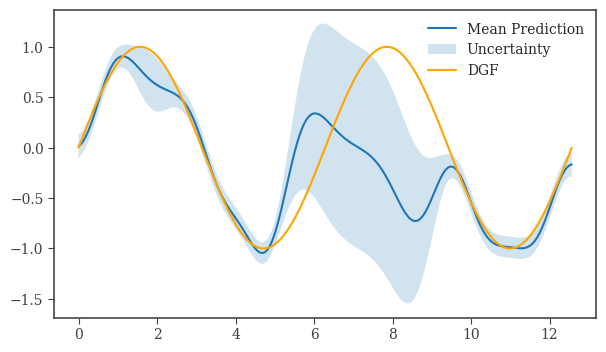

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

y_pred = y_pred.ravel()

std = np.diag(y_cov) ** 0.5
ax.plot(x, y_pred, label="Mean Prediction")
ax.fill_between(x.ravel(), y_pred - std, y_pred + std, label="Uncertainty", alpha=0.2)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.legend()

plt.show()

## Kernels

The kernel has a large influence on the prediction results. For example, when using a linear kernel

$$
k(\mathbf{x}, \mathbf{y}) = \mathbf{x}^T\mathbf{y}
$$

the GP is equivalent to Bayesian Linear Regression. The kernel also has an impact on the uncertainty estimation
and the smoothness of the GP.

In [6]:
res = []
for kernel in ["Linear", "RBF", "Exponential"]:
    gp = GP(kernel=kernel.lower())

    gp = gp.fit(x_short, y)
    y_pred, y_cov = gp.predict(x)

    y_std = np.diag(y_cov) ** 0.5

    res.append((kernel, y_pred.ravel(), y_std))

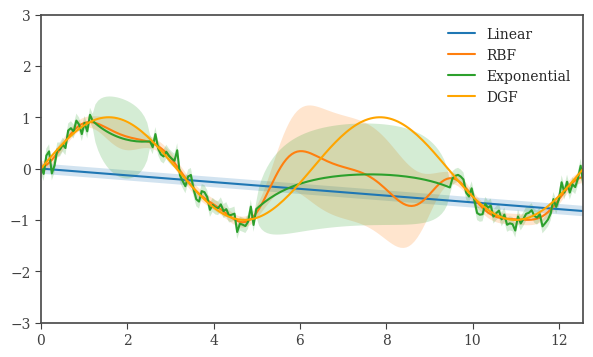

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

for (label, y_pred, std) in res:
    ax.plot(x, y_pred, label=label)
    ax.fill_between(x.ravel(), y_pred - std, y_pred + std, alpha=0.2)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.set_ylim(-3, 3)
ax.set_xlim(0, np.max(x))
ax.legend()

plt.show()

## Hyperparameter Selection

In [8]:
import itertools

h = [0.1, 1.0, 10.0]
sigma_n = [0.1, 1.0]

res = []
for (sigma_n, h) in list(itertools.product(sigma_n, h)):
    gp = GP(kernel="rbf", h=h, sigma_n=sigma_n)

    gp = gp.fit(x_short, y)
    y_pred, y_cov = gp.predict(x)

    y_std = np.diag(y_cov) ** 0.5

    res.append((h, sigma_n, y_pred.ravel(), y_std))

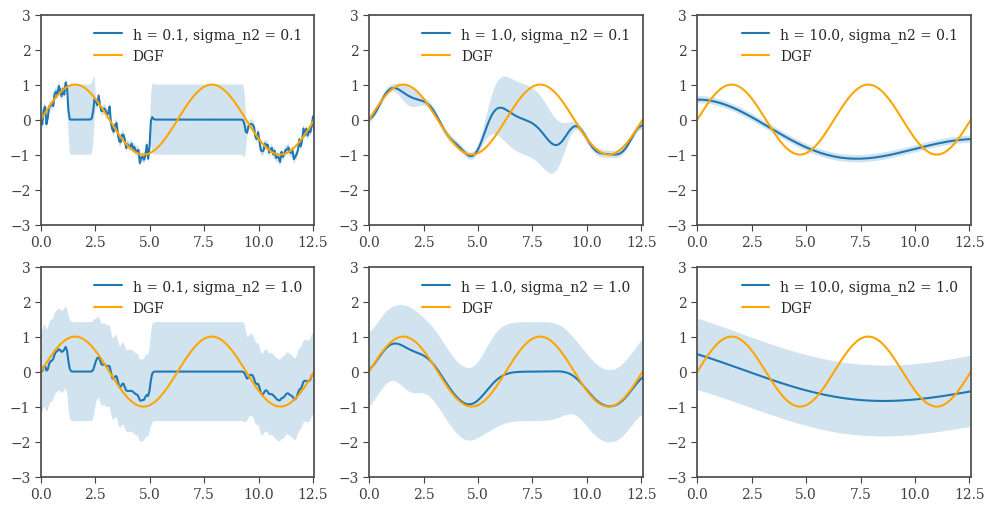

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    h, sigma_n, y_pred, y_std = res[i]
    ax.plot(x, y_pred, label=f"h = {h}, sigma_n2 = {sigma_n}")
    ax.fill_between(x.ravel(), y_pred - y_std, y_pred + y_std, alpha=0.2)
    ax.plot(x, np.sin(x), label="DGF", color="orange")

    ax.set_ylim(-3, 3)
    ax.set_xlim(0, np.max(x))
    ax.legend()

plt.show()

The choice of hyperparameters has a significant impact on the Gaussian Process. In the example above, there are two hyperparameters to optimize. The first one is the bandwidth parameter $h$ of the radial basis function, which is the kernel function. The second one is the irreducible noice variance $\sigma_n^2$.

The example shows that the bandwidth plays a crucial role in how smooth the line is. With a higher bandwidth, the line becomes increasingly smoother. However, at a certain level, the function is almost too smooth and does not follow the true DGF anymore. At the same time, if $\sigma_n^2$ is too large, even areas where there is a lot of training data have too high uncertainty.

In [15]:
import math
import itertools

h = [0.1, 0.2, 0.5, 0.9, 1.0, 2.0, 10.0]
sigma_n = [0.01, 0.1, 0.5, 1.0]

res = []
best_config = {}
best_score = math.inf
for (h, sigma_n) in list(itertools.product(h, sigma_n)):
    gp = GP(kernel="rbf", h=h, sigma_n=sigma_n)

    score = cross_validation(gp, x_short, y, neg_log_probability, probabilistic=True)

    print(f"GP with h = {h}, sigma_n = {sigma_n} CV-NLP: {float(score):.4f}")
    if score < best_score:
        best_score = score
        best_config = {"h": h, "sigma_n": sigma_n}

print(f"Best config: h = {best_config['h']}, sigma_n = {best_config['sigma_n']}")

GP with h = 0.1, sigma_n = 0.01 CV-NLP: 0.1575
0.15747546509682228
GP with h = 0.1, sigma_n = 0.1 CV-NLP: 0.1981
GP with h = 0.1, sigma_n = 0.5 CV-NLP: 0.7462
GP with h = 0.1, sigma_n = 1.0 CV-NLP: 1.1997
GP with h = 0.2, sigma_n = 0.01 CV-NLP: 63.1932
GP with h = 0.2, sigma_n = 0.1 CV-NLP: -0.1194
-0.11943484137834759
GP with h = 0.2, sigma_n = 0.5 CV-NLP: 0.5089
GP with h = 0.2, sigma_n = 1.0 CV-NLP: 1.0900
GP with h = 0.5, sigma_n = 0.01 CV-NLP: 121.4016
GP with h = 0.5, sigma_n = 0.1 CV-NLP: -0.1655
-0.16550388402258692
GP with h = 0.5, sigma_n = 0.5 CV-NLP: 0.3818
GP with h = 0.5, sigma_n = 1.0 CV-NLP: 1.0088
GP with h = 0.9, sigma_n = 0.01 CV-NLP: 117.9627
GP with h = 0.9, sigma_n = 0.1 CV-NLP: -0.0983
GP with h = 0.9, sigma_n = 0.5 CV-NLP: 0.3430
GP with h = 0.9, sigma_n = 1.0 CV-NLP: 0.9854
GP with h = 1.0, sigma_n = 0.01 CV-NLP: 107.4372
GP with h = 1.0, sigma_n = 0.1 CV-NLP: -0.0571
GP with h = 1.0, sigma_n = 0.5 CV-NLP: 0.3398
GP with h = 1.0, sigma_n = 1.0 CV-NLP: 0.9826
GP

Cross-validation is a common tool used to determine the best kernel parameters. Since GPs are capable of predicting a distribution for each observation, the negative predictive log probability can be minimized in order to find the best hyperparameters.

In [18]:
h, sigma_n = best_config["h"], best_config["sigma_n"]
gp = GP(kernel="rbf", h=h, sigma_n=sigma_n)

gp = gp.fit(x_short, y)
y_pred, y_cov = gp.predict(x)

y_std = np.diag(y_cov) ** 0.5
y_pred = y_pred.ravel()

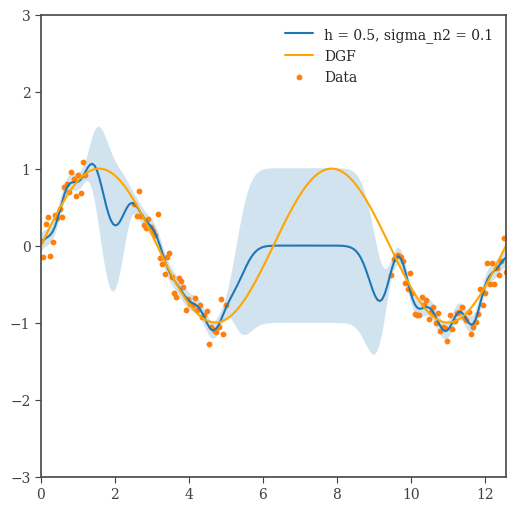

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x, y_pred, label=f"h = {h}, sigma_n2 = {sigma_n}")
ax.fill_between(x.ravel(), y_pred - y_std, y_pred + y_std, alpha=0.2)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.scatter(x_short, y, label="Data", s=10)

ax.set_ylim(-3, 3)
ax.set_xlim(0, np.max(x))
ax.legend()

plt.show()

Deciding whether the selection hyperparameters of is optimal is difficult, but the selection above shows good behavior: The line is smooth and is able to follow the true data-generating function well when enough data points exist. In cases where this is not true, the line seems a bit arbitrary. Furthermore, the uncertainty is high in areas where data is sparse, which is exactly what we aim for.